In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset using the correct file name
df = pd.read_csv('CarPrice_Assignment.csv')

# Display the first 5 rows to understand the dataset structure
print("First 5 rows of the Car Price dataset:")
df.head()

First 5 rows of the Car Price dataset:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [2]:
# Check for any missing values in the dataset
print("Checking for missing values in each column:")
print(df.isnull().sum())

# Drop 'car_ID' as it is an index column and has no predictive power
df = df.drop(columns=['car_ID'])

print("\nDataset dimensions after dropping unnecessary columns:")
print(df.shape)

Checking for missing values in each column:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

Dataset dimensions after dropping unnecessary columns:
(205, 25)


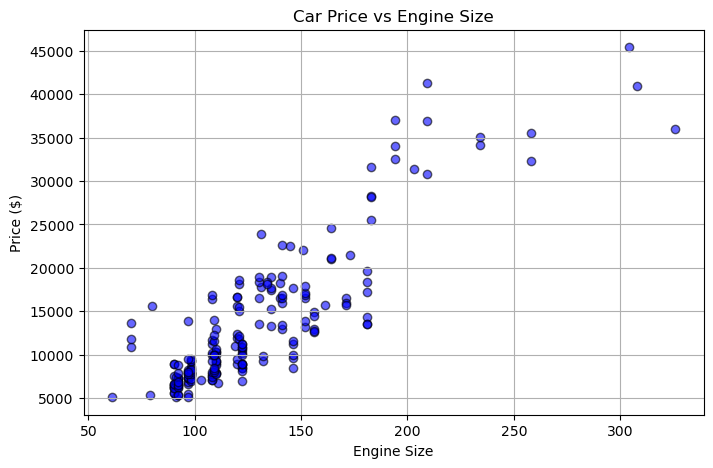

In [3]:
# Plot a scatter plot to visualize the relationship between Engine Size and Car Price
plt.figure(figsize=(8, 5))
plt.scatter(df['enginesize'], df['price'], color='blue', alpha=0.6, edgecolor='k')
plt.title('Car Price vs Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

In [4]:
# Select the most relevant numerical features for predicting car price
features = ['enginesize', 'horsepower', 'curbweight', 'highwaympg', 'carwidth']

X = df[features]  # Feature matrix (Independent variables)
y = df['price']   # Target vector (Dependent variable)

print("Features selected for training the model:")
print(X.columns.tolist())

Features selected for training the model:
['enginesize', 'horsepower', 'curbweight', 'highwaympg', 'carwidth']


In [5]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training data and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total number of training records: {X_train.shape[0]}")
print(f"Total number of testing records: {X_test.shape[0]}")

Total number of training records: 164
Total number of testing records: 41


In [6]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression Model
model = LinearRegression()

# Train the model using the training datasets
model.fit(X_train, y_train)

# Make predictions on the testing dataset
y_pred = model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [7]:
from sklearn.metrics import r2_score, mean_absolute_error

# Calculate evaluation metrics to check the model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"🎯 Model R-squared (Accuracy) Score: {r2 * 100:.2f}%")
print(f"📝 Mean Absolute Error: ${mae:.2f}")

🎯 Model R-squared (Accuracy) Score: 81.55%
📝 Mean Absolute Error: $2781.27
